 

<!-- Main div with background color and padding -->

<div style="background-color:#e6f2ff; padding: 20px;">

<!-- Image with margin and size adjustments -->

<img src="https://images.pexels.com/photos/2908984/pexels-photo-2908984.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1" alt="Image Alt Text" style="display:block; margin:auto; width:40%;"/>

<!-- Main title -->

<h1 style="font-family:Verdana; color:#333366; text-align:center; font-size:4em;">Learning Agency Lab - Automated Essay Scoring 2.0</h1>

<!-- Subtitle -->

<h3 style="font-family:Verdana; color:#666699; text-align:center; font-size:3em;">Improve upon essay scoring algorithms to improve student learning outcomes

</h3>

<!-- Author name -->

<h4 style="font-family:Verdana; text-align:center; font-size:2em;">by Jack Donohue</h4>

<!-- Section headers -->

<!-- Project Description -->

## <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#243139; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #000000"><a name="install-packages"></a>Project Description</p>

<p style="background-color:#e6f2ff;">Goal of the Competition & Link</p>

## <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#243139; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #000000"><a name="install-packages"></a>Goal of the Competition</p>

<p style="background-color:#e6f2ff;">Goal of the Competition & Link</p>


    
## <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#243139; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #000000"><a name="install-packages"></a>Table of Contents</p>

1. [Install Packages](#install-packages)
2. [Variable Settings](#var-settings)
3. [Kaggle Setup](#kaggle-setup)
4. [Data Loading](#data-loading)
5. [Exploratory Data Analysis (EDA)](#eda)
6. [Preprocessing](#preprocessing)
7. [Training](#training)
8. [Inference](#inference)
9. [Model Evaluation](#model-evaluation)

<br></br>

 

In [1]:
 
# Import Packages
import shutup; shutup.please()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras_tuner as kt
import seaborn as sns

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag, ne_chunk
from textblob import TextBlob

from textstat import flesch_reading_ease, smog_index

import spacy
from collections import Counter
from gensim import corpora, models
import pyLDAvis.gensim as gen
import pyLDAvis
import re

# Machine Learning & Data Preprocessing

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Deep Learning

from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Gensim
# from gensim.models import Word2Vec, KeyedVectors

# Progress bar
from tqdm import tqdm

# Keras Tuner
from keras_tuner.tuners import RandomSearch

# # Setting logging levels and environment variables
# tf.get_logger().setLevel(logging.ERROR)
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from textstat import flesch_reading_ease

2024-04-09 08:00:42.602906: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-09 08:00:42.603193: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-09 08:00:42.605543: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-09 08:00:42.631829: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-09 08:00:43.062190: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#243139; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #000000"> <a name="data-loading"></a>Data Loading</p>

### Competition data was cleaned in the 'clean-text-data.ipynb' notebook and loaded here for further processing and training

In [48]:
# Data Loading
# Placeholder for data loading code
train = pd.read_parquet('data/cleaned_train.parquet')
test = pd.read_parquet('data/cleaned_test.parquet')

In [49]:
train.head()

,essay_id,full_text,score,lowered_question,cleaned_text,clean_text
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live. the thin...,many people have car where they live . the th...
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...,people always wish they had the same technolog...
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...","we all heard about venus, the planet without a...","we all heard about venus , the planet without..."
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...","dear, state senator\n\nthis is a letter to arg...","dear , state senator\n\nthis is a letter to a..."


In [50]:
test.head()

,essay_id,full_text,lowered_question,cleaned_text,clean_text
0,000d118,Many people have car where they live. The thin...,many people have car where they live. the thin...,many people have car where they live. the thin...,many people have car where they live . the th...
1,000fe60,I am a scientist at NASA that is discussing th...,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...
2,001ab80,People always wish they had the same technolog...,people always wish they had the same technolog...,people always wish they had the same technolog...,people always wish they had the same technolog...


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#243139; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #000000"> <a name="preprocessing"></a>Preprocessing</p>

In [51]:
# helper functions to tokenize by word and by sentence and add to the dataframe
import nltk

def tokenize_by_word(text):
    return nltk.word_tokenize(text)

def tokenize_by_sentence(text):
    return nltk.sent_tokenize(text)

train['tokenized_word'] = train['clean_text'].apply(tokenize_by_word)
train['tokenized_sentence'] = train['clean_text'].apply(tokenize_by_sentence)



In [52]:
# helper function to lemmatize, remove stopwords and punctuation, and other important text preprocessing steps then add to the dataframe

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
import string

def preprocess_text_by_word(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = word_tokenize(text)
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
    text = ' '.join(text)
    return text

def preprocess_text_by_sentence(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = sent_tokenize(text)
    text = [word_tokenize(sentence) for sentence in text]
    text = [[lemmatizer.lemmatize(word) for word in sentence if word not in stop_words] for sentence in text]
    text = [' '.join(sentence) for sentence in text]
    return text

train['tokenized_word'] = train['clean_text'].apply(preprocess_text_by_word)
train['tokenized_sentence'] = train['clean_text'].apply(preprocess_text_by_sentence)

train.head()

,essay_id,full_text,score,lowered_question,cleaned_text,clean_text,tokenized_word,tokenized_sentence
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live. the thin...,many people have car where they live . the th...,many people car live thing know use car alot t...,[many people car live thing know use car alot ...
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,scientist nasa discussing face mar explaining ...,[scientist nasa discussing face mar explaining...
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...,people always wish they had the same technolog...,people always wish technology seen movie best ...,[people always wish technology seen movie best...
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...","we all heard about venus, the planet without a...","we all heard about venus , the planet without...",heard venus planet without almost oxygen earth...,[heard venus planet without almost oxygen eart...
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...","dear, state senator\n\nthis is a letter to arg...","dear , state senator\n\nthis is a letter to a...",dear state senator letter argue favor keeping ...,[dear state senator letter argue favor keeping...


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#243139; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #000000"> <a name="eda"></a>Exploratory Data Analysis (EDA)</p>

In [12]:
# Helper functions for EDA

def topic_modeling(texts, num_topics=5):
    """
    Perform topic modeling using LDA.
    """
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in tqdm(texts, desc='Creating corpus', leave=False)]
    lda_model = models.LdaModel(corpus, num_topics=num_topics, id2word=dictionary, passes=15)
    lda_display = gen.prepare(lda_model, corpus, dictionary)
    return lda_display

def sentiment_analysis(texts):
    """
    Perform sentiment analysis on the text using TextBlob.
    """
    return texts.apply(lambda x: TextBlob(x).sentiment.polarity)

def text_complexity(texts):
    """
    Calculate the Flesch Reading Ease score of the text using textstat.
    """
    return texts.apply(lambda x: flesch_reading_ease(x))


In [13]:
tokenized_words = pd.Series(train['tokenized_word'])

tokenized_sentences = pd.Series(train['tokenized_sentence'])

In [16]:

# Perform topic modeling on both summaries and prompts

print("Performing topic modeling on training text...")

lda_display_summaries = topic_modeling(tokenized_sentences)

print("Performing topic modeling on test text...")

lda_display_prompts = topic_modeling(tokenized_sentences)

# Perform sentiment analysis on summaries and prompts

print("Performing sentiment analysis on train...")

train['sentiment'] = sentiment_analysis(train['cleaned_text'])

print("Performing sentiment analysis on test...")

test['sentiment'] = sentiment_analysis(test['cleaned_text'])

# Calculate text complexity for summaries and prompts

print("Calculating text complexity for train...")

train['flesch_score'] = text_complexity(train['cleaned_text'])

print("Calculating text complexity for test...")

test['flesch_score'] = text_complexity(test['cleaned_text'])

Performing topic modeling on training text...


Performing topic modeling on test text...


Performing sentiment analysis on train...
Performing sentiment analysis on test...
Calculating text complexity for train...
Calculating text complexity for test...


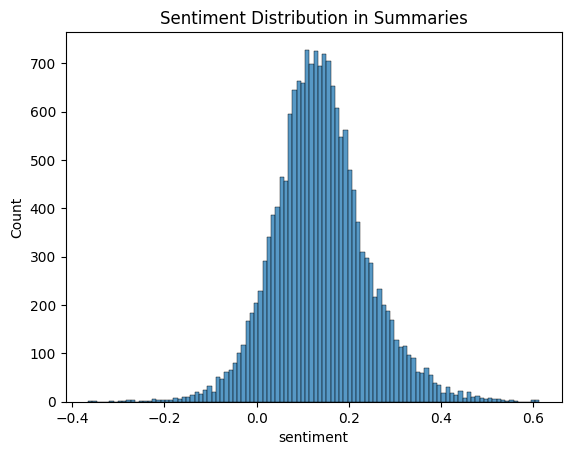

In [17]:

# Visualize sentiment and text complexity using histograms
sns.histplot(train['sentiment']).set_title('Sentiment Distribution in Essays')
plt.show()


 Preparing Visualizations.....


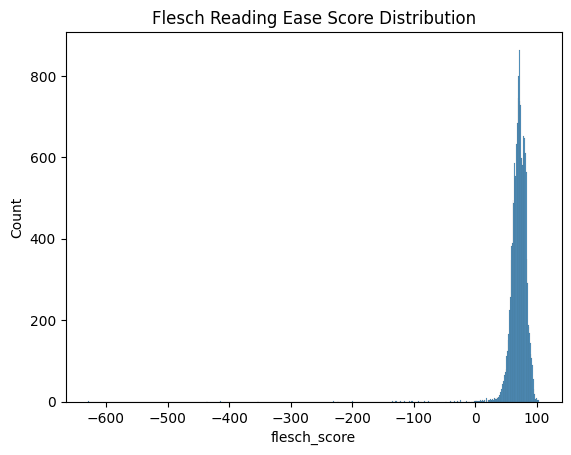

In [19]:
print('\n Preparing Visualizations.....')

sns.histplot(train['flesch_score']).set_title('Flesch Reading Ease Score Distribution')
plt.show()



 Preparing Visualizations.....


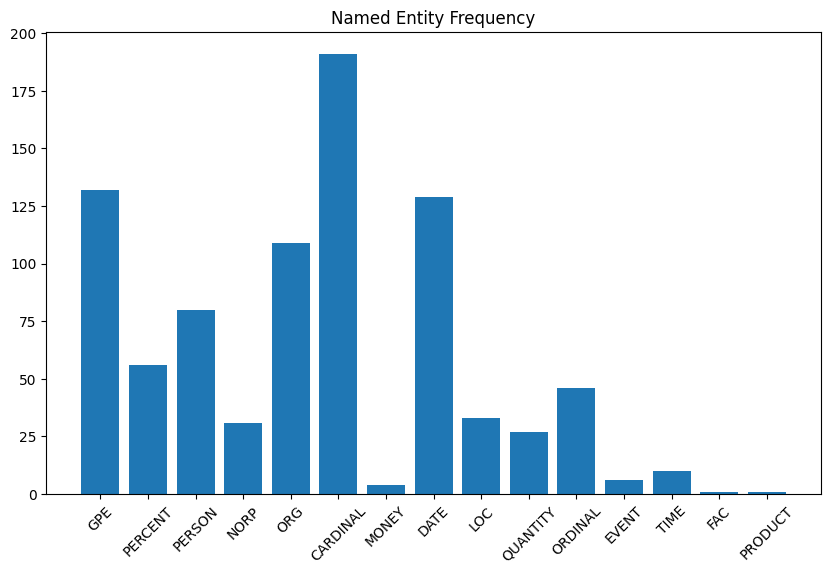

In [22]:
# Named Entity Recognition (Limiting to first 100 rows for demonstration)
nlp = spacy.load("en_core_web_sm")
texts = ' '.join(train['cleaned_text'][:100])
doc_text = nlp(texts)

print('\n Preparing Visualizations.....')

# Count the frequencies of named entity types in summaries and prompts
entity_freq_summaries = Counter([ent.label_ for ent in doc_text.ents])

# Visualize named entity frequencies
plt.figure(figsize=(10, 6))
plt.bar(entity_freq_summaries.keys(), entity_freq_summaries.values())
plt.title('Named Entity Frequency')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Preprocessing
# Placeholder for preprocessing code


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#243139; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #000000"> <a name="training"></a>Training</p>

In [53]:
def custom_train_validation_split(essays, test_size=0.2, random_state=56):
    
    """
    Custom function to perform train-validation split ensuring that
    the same prompt IDs are in both training and validation sets.

    Parameters:
    - summaries: DataFrame containing summaries and associated prompt_ids
    - prompts: DataFrame containing prompts and associated prompt_ids
    - test_size: Proportion of the dataset to be used as the validation set
    - random_state: Random seed for reproducibility

    Returns:
    - train_summaries: Training set containing summaries
    - validation_summaries: Validation set containing summaries
    - train_prompts: Training set containing prompts
    - validation_prompts: Validation set containing prompts
    """
    
    # Extract unique prompt IDs
    unique_essay_ids = essays['essay_id'].unique()

    # Split the unique prompt IDs into training and validation sets
    train_ids, validation_ids = train_test_split(unique_essay_ids, test_size=test_size, random_state=random_state)

    # Use these IDs to filter the original summaries and prompts DataFrames
    train_essays = essays[essays['essay_id'].isin(train_ids)]
    validation_essays = essays[essays['essay_id'].isin(validation_ids)]

    return train_essays, validation_essays


In [ ]:
train_essays, validation_essays = custom_train_validation_split(train, test_size=0.2, random_state=42)

In [54]:
train_essays.head()

,essay_id,full_text,score,lowered_question,cleaned_text,clean_text,tokenized_word,tokenized_sentence
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,scientist nasa discussing face mar explaining ...,[scientist nasa discussing face mar explaining...
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...,people always wish they had the same technolog...,people always wish technology seen movie best ...,[people always wish technology seen movie best...
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...","dear, state senator\n\nthis is a letter to arg...","dear , state senator\n\nthis is a letter to a...",dear state senator letter argue favor keeping ...,[dear state senator letter argue favor keeping...
6,0033037,The posibilty of a face reconizing computer wo...,2,the posibilty of a face reconizing computer wo...,the posibilty of a face reconizing computer wo...,the possibility of a face recognizing computer...,possibility face recognizing computer would he...,[possibility face recognizing computer would h...
7,0033bf4,What is the Seagoing Cowboys progam?\n\nIt was...,3,what is the seagoing cowboys progam?\n\nit was...,what is the seagoing cowboys progam?\n\nit was...,what is the seagoing cowboys progam ? \n\nit w...,seagoing cowboy progam help many country scarr...,[seagoing cowboy progam help many country scar...


In [58]:


def extract_features(texts, col = None, tfidf_vectorizer=None):
    
    """
    Extracts TF-IDF features from a list of texts.
    
    Parameters:
    - texts (list): A list of strings containing the text to be processed.
    - tfidf_vectorizer (TfidfVectorizer, optional): A pre-fitted TfidfVectorizer. If None, a new one will be fitted.
    
    Returns:
    - array: The TF-IDF features in dense array format.
    - TfidfVectorizer: The fitted or provided TfidfVectorizer instance.
    """
    
    # Initialize the TfidfVectorizer if not provided
    if tfidf_vectorizer is None:
        tfidf_vectorizer = TfidfVectorizer()
        tfidf_features = tfidf_vectorizer.fit_transform(texts[col])
    else:
        # Transform texts using the provided TfidfVectorizer
        tfidf_features = tfidf_vectorizer.transform(texts[col])

    texts['tfidf_features'] = tfidf_features
        
    # Convert the sparse array to a dense array
    return texts, tfidf_vectorizer



def preprocess_data(essays, tfidf_vectorizer=None):
    
    """
    Preprocesses and computes features for a dataset with text summaries and prompts.
    
    Parameters:
    - summaries (DataFrame): DataFrame containing the text summaries.
    - prompts (DataFrame): DataFrame containing the text prompts.
    - tfidf_vectorizer (TfidfVectorizer, optional): A pre-fitted TfidfVectorizer.
    
    Returns:
    - DataFrame: The preprocessed and feature-engineered DataFrame.
    """
    
    print('Preprocessing Data.......')

    # Extract TF-IDF features
    # tfidf_features, tfidf_vectorizer = extract_features(essays, col='cleaned_text',
    #                                                      tfidf_vectorizer=tfidf_vectorizer)

    stop_words = set(stopwords.words('english'))
    
    print('Generating Text Based Features.......')

    # Compute word count, sentence count, text length, and stopword count
    essays['word_count'] = essays['clean_text'].apply(lambda x: len(word_tokenize(x)))
    essays['sentence_count'] = essays['clean_text'].apply(lambda x: len(sent_tokenize(x)))
    essays['len_text'] = essays['clean_text'].str.len()
    essays['stop_count'] = essays['clean_text'].apply(lambda x: len([word for word in word_tokenize(x) if word in stop_words]))
    
    import string

    essays['punct_count'] = essays['clean_text'].apply(lambda x: len([char for char in x if char in string.punctuation]))
    essays['capital_count'] = essays['clean_text'].apply(lambda x: len([word for word in word_tokenize(x) if word.isupper()]))
    
    from nltk import pos_tag

    essays['noun_count'] = essays['clean_text'].apply(lambda x: len([word for word, pos in pos_tag(word_tokenize(x)) if pos.startswith('NN')]))
    
    from nltk import ne_chunk

    essays['ne_count'] = essays['clean_text'].apply(lambda x: len([chunk for chunk in ne_chunk(pos_tag(word_tokenize(x))) if hasattr(chunk, 'label')]))
    essays['avg_word_len'] = essays['clean_text'].apply(lambda x: sum(len(word) for word in word_tokenize(x)) / len(word_tokenize(x)) if len(word_tokenize(x)) > 0 else 0)
    essays['lex_div'] = essays['clean_text'].apply(lambda x: len(set(word_tokenize(x))) / len(word_tokenize(x)) if len(word_tokenize(x)) > 0 else 0)
    
    from textblob import TextBlob

    essays['polarity'] = essays['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
    essays['subjectivity'] = essays['clean_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
    
    from collections import Counter

    essays['most_common_word_count'] = essays['clean_text'].apply(lambda x: Counter(word_tokenize(x)).most_common(1)[0][1] if len(word_tokenize(x)) > 0 else 0)

    
    # # Calculate cosine similarity between the text and its corresponding prompt
    # print('Computing Cosine Similarity.......')
    # merged_data = compute_cosine_similarity(merged_data, 
    #                                         'treated_question_summaries', 
    #                                         'treated_question_prompts')
    
    return essays, tfidf_vectorizer


def compute_cosine_similarity(df, text_col, content_col):
    
    """
    Computes the cosine similarity between two columns of text in a DataFrame.
    
    Parameters:
    - df (DataFrame): The DataFrame containing the texts.
    - text_col (str): The name of the column containing the first set of texts.
    - content_col (str): The name of the column containing the second set of texts.
    
    Returns:
    - DataFrame: The DataFrame with an additional column for the computed cosine similarity.
    """
    
    # Combine texts from both columns to fit the TF-IDF vectorizer
    all_texts = df[text_col].tolist() + df[content_col].tolist()
    
    # Fit the TF-IDF vectorizer on the combined corpus
    vectorizer = TfidfVectorizer()
    vectorizer.fit(all_texts)
    
    # Generate TF-IDF vectors for both columns
    text_tfidf = vectorizer.transform(df[text_col])
    content_tfidf = vectorizer.transform(df[content_col])
    
    # Compute cosine similarity for each pair of text and content
    cosine_sim_values = [cosine_similarity(text_tfidf[i], content_tfidf[i])[0][0] for i in range(len(df))]
    
    # Add the computed cosine similarity values to the DataFrame
    df['cos_sim'] = cosine_sim_values
    
    return df


In [60]:
train_essays, tfidf_vectorizer = preprocess_data(train_essays)

Preprocessing Data.......
Generating Text Based Features.......


In [61]:
validation_essays, _ = preprocess_data(validation_essays, tfidf_vectorizer=tfidf_vectorizer)

Preprocessing Data.......
Generating Text Based Features.......


In [62]:
train_essays.head()

,essay_id,full_text,score,lowered_question,cleaned_text,clean_text,tokenized_word,tokenized_sentence,word_count,sentence_count,...,stop_count,punct_count,capital_count,noun_count,ne_count,avg_word_len,lex_div,polarity,subjectivity,most_common_word_count
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,scientist nasa discussing face mar explaining ...,[scientist nasa discussing face mar explaining...,373,23,...,201,37,0,71,0,3.597855,0.396783,0.101786,0.444643,19
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...,people always wish they had the same technolog...,people always wish technology seen movie best ...,[people always wish technology seen movie best...,610,24,...,280,56,0,126,0,4.140984,0.378689,0.168435,0.451264,28
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...","dear, state senator\n\nthis is a letter to arg...","dear , state senator\n\nthis is a letter to a...",dear state senator letter argue favor keeping ...,[dear state senator letter argue favor keeping...,430,16,...,197,47,0,107,0,4.223256,0.355814,0.165438,0.553994,39
6,0033037,The posibilty of a face reconizing computer wo...,2,the posibilty of a face reconizing computer wo...,the posibilty of a face reconizing computer wo...,the possibility of a face recognizing computer...,possibility face recognizing computer would he...,[possibility face recognizing computer would h...,198,7,...,95,16,0,46,0,4.353535,0.510101,0.014286,0.437500,13
7,0033bf4,What is the Seagoing Cowboys progam?\n\nIt was...,3,what is the seagoing cowboys progam?\n\nit was...,what is the seagoing cowboys progam?\n\nit was...,what is the seagoing cowboys progam ? \n\nit w...,seagoing cowboy progam help many country scarr...,[seagoing cowboy progam help many country scar...,402,26,...,176,48,0,75,0,4.022388,0.348259,0.245500,0.439167,22


In [63]:
validation_essays.head()

,essay_id,full_text,score,lowered_question,cleaned_text,clean_text,tokenized_word,tokenized_sentence,word_count,sentence_count,...,stop_count,punct_count,capital_count,noun_count,ne_count,avg_word_len,lex_div,polarity,subjectivity,most_common_word_count
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live. the thin...,many people have car where they live . the th...,many people car live thing know use car alot t...,[many people car live thing know use car alot ...,545,13,...,265,38,0,120,0,3.921101,0.429358,0.179676,0.540916,21
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...","we all heard about venus, the planet without a...","we all heard about venus , the planet without...",heard venus planet without almost oxygen earth...,[heard venus planet without almost oxygen eart...,519,24,...,205,61,0,127,0,4.339114,0.437380,0.094291,0.555147,29
5,0030e86,If I were to choose between keeping the electo...,4,if i were to choose between keeping the electo...,if i were to choose between keeping the electo...,if i were to choose between keeping the electo...,choose keeping electoral college abolishing wo...,[choose keeping electoral college abolishing w...,439,26,...,188,38,0,94,0,4.448747,0.428246,0.126214,0.461245,26
8,0036253,The challenge of exploring Venus\n\nThis stori...,2,the challenge of exploring venus\n\nthis stori...,the challenge of exploring venus\n\nthis stori...,the challenge of exploring venus\n\nthis stori...,challenge exploring venus storie challeng expl...,[challenge exploring venus storie challeng exp...,344,18,...,136,30,0,97,0,4.476744,0.441860,0.110292,0.597625,33
14,0065bd6,Driverless cars should not exsist it can cause...,3,driverless cars should not exsist it can cause...,driverless cars should not exsist it can cause...,driverless cars should not exsist it can cause...,driverless car exsist cause many accident poss...,[driverless car exsist cause many accident pos...,326,13,...,159,32,0,70,0,4.079755,0.389571,0.059774,0.529511,14


In [64]:
train_essays.columns

Index(['essay_id', 'full_text', 'score', 'lowered_question', 'cleaned_text',
       'clean_text', 'tokenized_word', 'tokenized_sentence', 'word_count',
       'sentence_count', 'len_text', 'stop_count', 'punct_count',
       'capital_count', 'noun_count', 'ne_count', 'avg_word_len', 'lex_div',
       'polarity', 'subjectivity', 'most_common_word_count'],
      dtype='object')

In [65]:
drop_cols = ['full_text','lowered_question', 'cleaned_text']

training = train_essays.copy()
validation = validation_essays.copy()

training.drop(columns=drop_cols, inplace= True)
validation_essays.drop(columns=drop_cols, inplace= True)



In [66]:
training.head()

,essay_id,score,clean_text,tokenized_word,tokenized_sentence,word_count,sentence_count,len_text,stop_count,punct_count,capital_count,noun_count,ne_count,avg_word_len,lex_div,polarity,subjectivity,most_common_word_count
1,000fe60,3,i am a scientist at nasa that is discussing th...,scientist nasa discussing face mar explaining ...,[scientist nasa discussing face mar explaining...,373,23,1763,201,37,0,71,0,3.597855,0.396783,0.101786,0.444643,19
2,001ab80,4,people always wish they had the same technolog...,people always wish technology seen movie best ...,[people always wish technology seen movie best...,610,24,3219,280,56,0,126,0,4.140984,0.378689,0.168435,0.451264,28
4,002ba53,3,"dear , state senator\n\nthis is a letter to a...",dear state senator letter argue favor keeping ...,[dear state senator letter argue favor keeping...,430,16,2316,197,47,0,107,0,4.223256,0.355814,0.165438,0.553994,39
6,0033037,2,the possibility of a face recognizing computer...,possibility face recognizing computer would he...,[possibility face recognizing computer would h...,198,7,1083,95,16,0,46,0,4.353535,0.510101,0.014286,0.437500,13
7,0033bf4,3,what is the seagoing cowboys progam ? \n\nit w...,seagoing cowboy progam help many country scarr...,[seagoing cowboy progam help many country scar...,402,26,2099,176,48,0,75,0,4.022388,0.348259,0.245500,0.439167,22


In [67]:
validation.head()

,essay_id,full_text,score,lowered_question,cleaned_text,clean_text,tokenized_word,tokenized_sentence,word_count,sentence_count,...,stop_count,punct_count,capital_count,noun_count,ne_count,avg_word_len,lex_div,polarity,subjectivity,most_common_word_count
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live. the thin...,many people have car where they live . the th...,many people car live thing know use car alot t...,[many people car live thing know use car alot ...,545,13,...,265,38,0,120,0,3.921101,0.429358,0.179676,0.540916,21
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...","we all heard about venus, the planet without a...","we all heard about venus , the planet without...",heard venus planet without almost oxygen earth...,[heard venus planet without almost oxygen eart...,519,24,...,205,61,0,127,0,4.339114,0.437380,0.094291,0.555147,29
5,0030e86,If I were to choose between keeping the electo...,4,if i were to choose between keeping the electo...,if i were to choose between keeping the electo...,if i were to choose between keeping the electo...,choose keeping electoral college abolishing wo...,[choose keeping electoral college abolishing w...,439,26,...,188,38,0,94,0,4.448747,0.428246,0.126214,0.461245,26
8,0036253,The challenge of exploring Venus\n\nThis stori...,2,the challenge of exploring venus\n\nthis stori...,the challenge of exploring venus\n\nthis stori...,the challenge of exploring venus\n\nthis stori...,challenge exploring venus storie challeng expl...,[challenge exploring venus storie challeng exp...,344,18,...,136,30,0,97,0,4.476744,0.441860,0.110292,0.597625,33
14,0065bd6,Driverless cars should not exsist it can cause...,3,driverless cars should not exsist it can cause...,driverless cars should not exsist it can cause...,driverless cars should not exsist it can cause...,driverless car exsist cause many accident poss...,[driverless car exsist cause many accident pos...,326,13,...,159,32,0,70,0,4.079755,0.389571,0.059774,0.529511,14


In [70]:
training.to_parquet('data/training_features.parquet')
validation.to_parquet('data/validation_features.parquet')

In [69]:
feature_cols = []

for col in training.columns:
    if (col != 'essay_id') and (col != 'score'):
        feature_cols.append(col) 


# Select relevant columns (replace with actual column names)

training_labels = training['score']

validation_labels = validation['score']

train_features = training[feature_cols].values

val_features = validation[feature_cols].values

# test_features = test[feature_cols].values


# Standardize the features if needed

scaler = StandardScaler()


train_features = scaler.fit_transform(train_features)

val_features = scaler.transform(val_features)

# test_features = scaler.transform(test_features)



# Optionally, convert back to DataFrame

train_labels = pd.DataFrame(training_labels, columns=['score'],
                             index=training_labels.index)

val_labels = pd.DataFrame(validation_labels, columns=['score'], 
                          index=validation_labels.index)

import pickle

# Save the scaler and other processed data
# with open('target_scaler.pkl', 'wb') as f:
#     pickle.dump(target_scaler, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
    
# Combine TF-IDF features with the selected features

# combined_train_features = np.hstack((tfidf_train_features, train_features))

# combined_test_features = np.hstack((tfidf_test_features, test_features))


ValueError: could not convert string to float: 'i am a scientist at nasa that is discussing the   "  face  "   on mars .  i will be explaining how the   "  face  "   is a land form .  by sharing my information about this isue i will tell you just that . \n\nfirst off ,  how could it be a martins drawing .  there is no plant life on mars as of rite now that we know of ,  which means so far as we know it is not possible for any type of life .  that explains how it could not be made by martians .  also why and how would a martian build a face so big .  it just does not make any since that a martian did this . \n\nnext ,  why it is a landform .  there are many landforms that are weird here in america ,  and there is also landforms all around the whole earth .  many of them look like something we can relate to like a snake a turtle a human .  .  .  so if there are landforms on earth dont you think landforms are on mars to ?  of course !  why not ?  it is just unique that the landform on mar

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#243139; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #000000"> <a name="inference"></a>Inference</p>

In [ ]:
# Inference
# Placeholder for inference code


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#243139; font-size:140%; text-align:left;padding: 0px; border-bottom: 3px solid #000000"> <a name="model-evaluation"></a>Model Evaluation</p>

In [ ]:
# Model Evaluation
# Placeholder for model evaluation code
